In [1]:
# 二、动手实现 logistic 回归（使用torch.nn）

# 导入所需包和所需模块
import torch
import torch.nn as nn
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from torch.nn import BCELoss
import random
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix

In [2]:
# 定义绘图函数
def figplot(fignum=1,loss=[],acc=[]):
    plt.figure(figsize=(8,3))
    plt.suptitle('Figure '+str(fignum))
    # 打印损失值
    plt.subplot(121)
    plt.ylabel('Loss')
    plt.plot(loss[0],label='Train Loss')
    plt.plot(loss[1],label='Test Loss')
    plt.legend()
    # 打印正确率
    plt.subplot(122)
    plt.ylabel('Accuracy')
    plt.plot(acc[0],label='Train Acc')
    plt.plot(acc[1],label='Test Acc')
    plt.legend()
    # plt.grid()
    plt.show()

In [3]:
def sigmoid(x):
    return 1/(1+torch.exp(-x))

In [4]:
# 构造人工数据集
def create_data(num_examples,num_inputs):
    features = torch.tensor(np.random.rand(num_examples,num_inputs), dtype=torch.float)

    labels_x = torch.zeros(num_examples, dtype=torch.float)
    for i in range(num_inputs):
        labels_x += true_w[i] * features[:, i]
    labels = sigmoid(labels_x + true_b) # 生成标签

    noise = torch.tensor(np.random.normal(0, 0.01, size=labels.size()), dtype=torch.float) # 增加噪声
    labels += noise 
    
    num_0, num_1 = 0, 0
    for i in range(num_examples):
        if labels[i] < 0.5:
            labels[i] = 0
            num_0 += 1
        else:
            labels[i] = 1
            num_1 += 1
        labels = labels.view(-1,1)
    return features, labels, num_0, num_1

num_inputs = 4
true_w = [9.13, -7.091, 0.407, -1.134]
true_b = -1.379
train_examples, test_examples = 3500, 1500
train_data,train_labels, train_0, train_1 = create_data(train_examples,num_inputs)
test_data, test_labels, test_0, test_1 = create_data(test_examples,num_inputs)
print("共生成训练样本量: %d，其中 标签为'0' %d 样本， 标签为'1' %d 样本"%(train_examples,train_0,train_1))
print("共生成测试样本量: %d，其中 标签为'0' %d 样本， 标签为'1' %d 样本"%(test_examples,test_0,test_1))

共生成训练样本量: 3500，其中 标签为'0' 1990 样本， 标签为'1' 1510 样本
共生成测试样本量: 1500，其中 标签为'0' 849 样本， 标签为'1' 651 样本


In [5]:
# 模型定义
class myLogistic(nn.Module):  
    def __init__(self,num_examples):  
        super(myLogistic, self).__init__()  
        self.liner = nn.Linear(num_examples, 1)  
        self.s = nn.Sigmoid()  

    def forward(self, x): # 向前传播
        x = self.liner(x)  
        x = self.s(x)  
        return x  

Epoch: 1	    Train loss:36.36054 Train acc: 0.612    Test loss:15.08578 Test acc: 0.697
Epoch: 10	    Train loss:20.47772 Train acc: 0.960    Test loss:8.83542 Test acc: 0.961
Epoch: 20	    Train loss:15.51948 Train acc: 0.980    Test loss:6.69433 Test acc: 0.982
Epoch: 30	    Train loss:13.19437 Train acc: 0.987    Test loss:5.73000 Test acc: 0.989
Epoch: 40	    Train loss:11.80197 Train acc: 0.990    Test loss:5.13831 Test acc: 0.989
Epoch: 50	    Train loss:10.82605 Train acc: 0.991    Test loss:4.68124 Test acc: 0.991
Epoch: 60	    Train loss:10.12322 Train acc: 0.993    Test loss:4.40761 Test acc: 0.992
Epoch: 70	    Train loss:9.54290 Train acc: 0.993    Test loss:4.10294 Test acc: 0.993
Epoch: 80	    Train loss:9.09231 Train acc: 0.993    Test loss:3.98409 Test acc: 0.993
Epoch: 90	    Train loss:8.70158 Train acc: 0.994    Test loss:3.76632 Test acc: 0.994
Epoch: 100	    Train loss:8.37354 Train acc: 0.994    Test loss:3.61326 Test acc: 0.994
Epoch: 110	    Train loss:8.09326 T

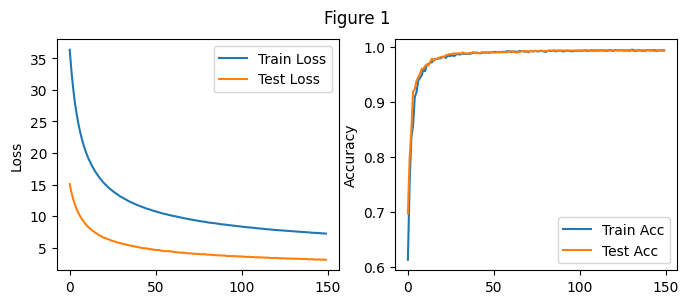

In [6]:
# 训练
train_dataset = TensorDataset(train_data,train_labels)
test_dataset = TensorDataset(test_data,test_labels)
train_dataloader = DataLoader(dataset=train_dataset,batch_size=64,shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset,batch_size=64,shuffle=True)
model = myLogistic(num_inputs)  # logistics模型
criterion = BCELoss()   # 损失函数
optimizer = torch.optim.SGD(model.parameters(),lr=0.1)
epochs = 150 # 训练轮数
train_all_loss = []
test_all_loss = []
train_acc_all = []
test_acc_all = []
max_acc = 0
for epoch in range(epochs):
    train_l, train_acc_num = 0, 0
    for data, labels in train_dataloader:
        pred = model(data)
        train_each_loss = criterion(pred, labels)
        train_l += train_each_loss.item()
        optimizer.zero_grad()  # 梯度清零
        train_each_loss.backward() # 反向传播
        optimizer.step()  # 梯度更新
        labels_pred = torch.tensor(np.where(pred>0.5, 1, 0),dtype=torch.float32)
        train_acc_num += (labels_pred==labels).sum(0).item()
    train_all_loss.append(train_l)
    # max_acc = max(train_acc_num/train_examples,max_acc)
    # print(acc,train_examples)
    train_acc_all.append(train_acc_num/train_examples)  

    # 测试集合上测试(将测试集合作为验证集)
    with torch.no_grad():
        loss_all = 0
        acc_num = 0
        for data, labels in test_dataloader:
            pred = model(data)
            loss = criterion(pred, labels)
            loss_all += loss.item()
            labels_pred = torch.tensor(np.where(pred>0.5, 1, 0),dtype=torch.float32)
            acc_num += (labels_pred==labels).sum(0).item()
        test_all_loss.append(loss_all)
        test_acc_all.append(acc_num/test_examples)
    if epoch==0 or (epoch+1) % 10 == 0:
        print('Epoch: %d\t    Train loss:%.5f Train acc: %.3f    Test loss:%.5f Test acc: %.3f'%(
            epoch+1,train_l, train_acc_num/train_examples, loss_all, acc_num/test_examples))
        
# 绘图
figplot(fignum=1,loss=[train_all_loss,test_all_loss],acc=[train_acc_all,test_acc_all])
